![PIC UPV PERTE Chip Chair Logo](https://www.pic-chair.upv.es/wp-content/uploads/2024/05/logo-upv-horizontal.png)
![PIC UPV PERTE Chip Chair Logo](https://www.pic-chair.upv.es/wp-content/uploads/2024/06/logos-perte-chip-1024x119.png)


# Laboratory 2.0. Coupler Design

## 0. Imports 

### 0.1. General libraries

In [1]:
import matplotlib.pyplot as plt
import numpy as np

import tidy3d as td
import gplugins.tidy3d as gt

nm = 1e-3
wavelength = np.linspace(1500, 1600) * nm
f = td.C_0 / wavelength


### 0.2. Functions by us

In [2]:
from upvfab_design_tools import MMI_EME, DC_EME

In [3]:
nitride_complex = td.material_library["Si3N4"]["Luke2015PMLStable"].eps_model(f)
nitride_index, nitride_k = td.Medium.eps_complex_to_nk(nitride_complex)
box_complex = td.material_library["SiO2"]["Horiba"].eps_model(f)
box_index, box_k = td.Medium.eps_complex_to_nk(box_complex)

## LO.1. Directional coupler length and coupling coefficient

The total power transferred to the output is modeled using the coupling coefficient (K). This coefficient depends on the relationship between the physical length of the coupling region and the beating length:

<img src="k.png" alt="Coupling Coefficient Equation" width="400">

Simulate a directional coupler that implements two deep waveguide cores of 1.2 microns width and with a gap of 600 nm between them. 
- Plot the transfer function: K vs L/Lpi
- Comment the results: distance needed for a complete energy transfer between waveguides, distance needed for splitting power in half.. 

## LO.2. 2x2 Directional Coupler

Here, you will use some functions provided by us (check **0. Imports** for more details) to simulate the propagation in a 2x2 directional coupler. Please read all the comments in the following code carefully and **make changes only to the lines marked with the #Student tag**

In [4]:
# Simulation flow for Directional Couplers
# Define your geometrical parameters here
wg_gap = 0.6  # Student. Gap between waveguides
wg_width = 1.2 # Student. Core waveguides width

d = wg_width + wg_gap
wg_N = 2

m = DC_EME() # Here you instantiate a Directional Coupler to be simulated with the Eigen-mode expansion (EME) algorithm.
m.MMI_num_modes = 12 # Number of modes to be calculated. Here, the higher, the better since we are going to calculate
                    # the propagation based on the mode decomposition. 
m.DC_wg_gap = wg_gap # Gap between waveguides
m.DC_wg_width = wg_width # Width of the waveguides core
m.DC_N_waveguides = wg_N

# 1) Compute de DC modes - Only execute whenever a geometrical parameter is changed. Takes time to find the modes. 
m.find_all_modes()

# 2) Get the L_pi 
L_pi = m.get_L_pi()
print("L_pi = ", L_pi, " µm")

c:\Users\cfp\DISEÑO\pic-upv-lab2\.venv\Lib\site-packages\skfem\assembly\form\linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


L_pi =  94.02742605178396  µm


c:\Users\cfp\DISEÑO\pic-upv-lab2\.venv\Lib\site-packages\skfem\assembly\form\linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/1881 [00:00<?, ?it/s]

------- Pameters -------
MMI length 94.0274
MMI length increment 0.0000
IO wg width 1.0000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.9688
Total OUT power: 0.9583
Excess loss [dB] =  0.1851
------------------------
Power over OUTs:  ['0.0012', '0.9570']
Ratio over OUTs ['0.0013', '0.9987']


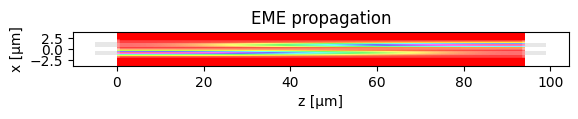

In [5]:
# IMPORTANT!!! 
# # If you DON'T change any geometrical parameter
# (waveguide widths or gap) you can skip last cell. 
# YOU CAN RUN the lines below as many times as you wish
# (SAVES TIME)

# 3) Configure DC
# DC I/O number
m.n_IN = 2
m.n_OUT = 2


m.L_MMI = L_pi # Since we use the same library for propagation simulations of MMI and DC 
                    # some variables might be identified as "MMI". Sorry about that (: 
                    # Might change in the future 

# 4) Run propagation - get power transfer and plot propagation
m.propagation()

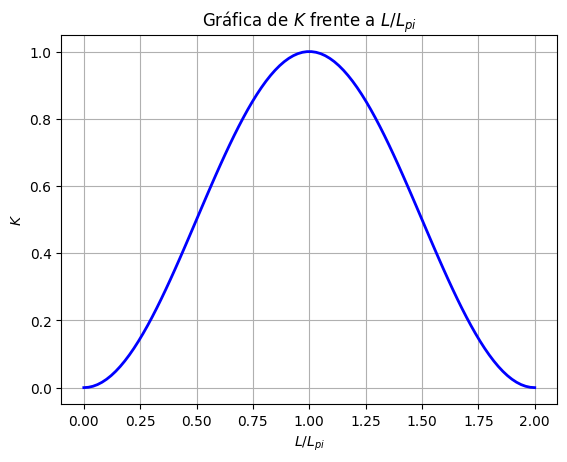

In [7]:
L= np.linspace( 0, 2* L_pi, 100)
frac_L_Lpi= L/ L_pi

K= (np.sin( 0.5*np.pi*frac_L_Lpi))**2
plt.plot(frac_L_Lpi, K, color='blue', linewidth=2)

plt.title('Gráfica de $K$ frente a $L/L_{pi}$')
plt.xlabel('$L / L_{pi}$')
plt.ylabel('$K$')
plt.grid(True)
plt.show()

distancia lpi, se me pasa toda la potencia a la guia de arriba. Lpi/2 tenemos 0.5 y 0.5 dividido.

c:\Users\cfp\DISEÑO\pic-upv-lab2\.venv\Lib\site-packages\skfem\assembly\form\linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


L_pi =  94.02742605176876  µm


c:\Users\cfp\DISEÑO\pic-upv-lab2\.venv\Lib\site-packages\skfem\assembly\form\linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/4000 [00:00<?, ?it/s]

------- Pameters -------
MMI length 200.0000
MMI length increment 0.0000
IO wg width 1.0000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.9688
Total OUT power: 0.9583
Excess loss [dB] =  0.1851
------------------------
Power over OUTs:  ['0.9195', '0.0388']
Ratio over OUTs ['0.9595', '0.0405']


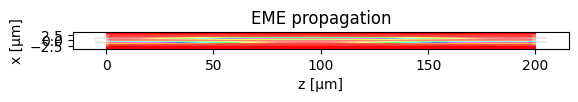

In [25]:
# Simulation flow for Directional Couplers
# Define your geometrical parameters here
wg_gap =  0.6 # Student. Gap between waveguides
wg_width = 1.2 # Student. Core waveguides width

d = wg_width + wg_gap
wg_N = 2

m1 = DC_EME() # Here you instantiate a Directional Coupler to be simulated with the Eigen-mode expansion (EME) algorithm.
m1.MMI_num_modes = 12 # Number of modes to be calculated. Here, the higher, the better since we are going to calculate
                    # the propagation based on the mode decomposition. 
m1.DC_wg_gap = wg_gap # Gap between waveguides
m1.DC_wg_width = wg_width # Width of the waveguides core
m1.DC_N_waveguides = wg_N

# 1) Compute de DC modes - Only execute whenever a geometrical parameter is changed. Takes time to find the modes. 
m1.find_all_modes()
    
# 2) Get the L_pi 
L_pi = m1.get_L_pi()
print("L_pi = ", L_pi, " µm")

m1.n_IN = 2
m1.n_OUT = 2


m1.L_MMI = 200 
                    
                    
m1.propagation()

c:\Users\cfp\DISEÑO\pic-upv-lab2\.venv\Lib\site-packages\skfem\assembly\form\linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


L_pi =  128.065673339184  µm


c:\Users\cfp\DISEÑO\pic-upv-lab2\.venv\Lib\site-packages\skfem\assembly\form\linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/4000 [00:00<?, ?it/s]

------- Pameters -------
MMI length 200.0000
MMI length increment 0.0000
IO wg width 1.0000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.9841
Total OUT power: 0.9737
Excess loss [dB] =  0.1157
------------------------
Power over OUTs:  ['0.5805', '0.3932']
Ratio over OUTs ['0.5961', '0.4039']


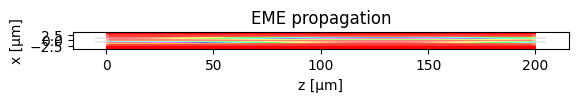

In [26]:
wg_gap =  0.7
wg_width = 1.2 # Student. Core waveguides width
d = wg_width + wg_gap
wg_N = 2

m1 = DC_EME() # Here you instantiate a Directional Coupler to be simulated with the Eigen-mode expansion (EME) algorithm.
m1.MMI_num_modes = 12 # Number of modes to be calculated. Here, the higher, the better since we are going to calculate
                    # the propagation based on the mode decomposition. 
m1.DC_wg_gap = wg_gap # Gap between waveguides
m1.DC_wg_width = wg_width # Width of the waveguides core
m1.DC_N_waveguides = wg_N

m1.find_all_modes()
L_pi = m1.get_L_pi()
print("L_pi = ", L_pi, " µm")
m1.L_MMI = 200 
m1.propagation()

c:\Users\cfp\DISEÑO\pic-upv-lab2\.venv\Lib\site-packages\skfem\assembly\form\linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


L_pi =  173.96389977139225  µm


c:\Users\cfp\DISEÑO\pic-upv-lab2\.venv\Lib\site-packages\skfem\assembly\form\linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/4000 [00:00<?, ?it/s]

------- Pameters -------
MMI length 200.0000
MMI length increment 0.0000
IO wg width 1.0000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.9882
Total OUT power: 0.9779
Excess loss [dB] =  0.0968
------------------------
Power over OUTs:  ['0.0539', '0.9240']
Ratio over OUTs ['0.0551', '0.9449']


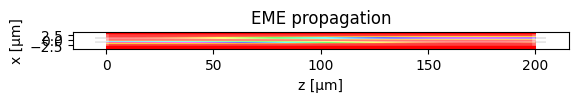

In [27]:
wg_gap =  0.8
wg_width = 1.2 
d = wg_width + wg_gap
wg_N = 2

m1 = DC_EME() 
m1.MMI_num_modes = 12
                    
m1.DC_wg_gap = wg_gap 
m1.DC_wg_width = wg_width 
m1.DC_N_waveguides = wg_N

m1.find_all_modes()
L_pi = m1.get_L_pi()
print("L_pi = ", L_pi, " µm")
m1.L_MMI = 200 
m1.propagation()

c:\Users\cfp\DISEÑO\pic-upv-lab2\.venv\Lib\site-packages\skfem\assembly\form\linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


L_pi =  235.77407047787594  µm


c:\Users\cfp\DISEÑO\pic-upv-lab2\.venv\Lib\site-packages\skfem\assembly\form\linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/4000 [00:00<?, ?it/s]

------- Pameters -------
MMI length 200.0000
MMI length increment 0.0000
IO wg width 1.0000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.9832
Total OUT power: 0.9729
Excess loss [dB] =  0.1192
------------------------
Power over OUTs:  ['0.0549', '0.9180']
Ratio over OUTs ['0.0564', '0.9436']


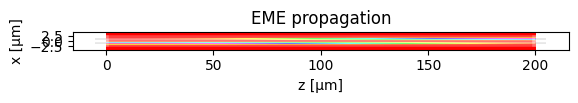

In [28]:
wg_gap =  0.9
wg_width = 1.2 
d = wg_width + wg_gap
wg_N = 2

m1 = DC_EME() 
m1.MMI_num_modes = 12
                    
m1.DC_wg_gap = wg_gap 
m1.DC_wg_width = wg_width 
m1.DC_N_waveguides = wg_N

m1.find_all_modes()
L_pi = m1.get_L_pi()
print("L_pi = ", L_pi, " µm")
m1.L_MMI = 200
m1.propagation()

c:\Users\cfp\DISEÑO\pic-upv-lab2\.venv\Lib\site-packages\skfem\assembly\form\linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


L_pi =  318.88415207666543  µm


c:\Users\cfp\DISEÑO\pic-upv-lab2\.venv\Lib\site-packages\skfem\assembly\form\linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/4000 [00:00<?, ?it/s]

------- Pameters -------
MMI length 200.0000
MMI length increment 0.0000
IO wg width 1.0000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.9663
Total OUT power: 0.9561
Excess loss [dB] =  0.1948
------------------------
Power over OUTs:  ['0.2922', '0.6640']
Ratio over OUTs ['0.3056', '0.6944']


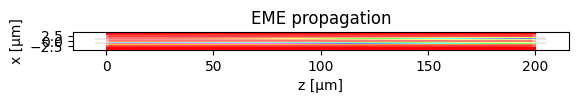

In [29]:
wg_gap =  1
wg_width = 1.2 
d = wg_width + wg_gap
wg_N = 2

m1 = DC_EME() 
m1.MMI_num_modes = 12
                    
m1.DC_wg_gap = wg_gap 
m1.DC_wg_width = wg_width 
m1.DC_N_waveguides = wg_N

m1.find_all_modes()
L_pi = m1.get_L_pi()
print("L_pi = ", L_pi, " µm")
m1.L_MMI = 200 
m1.propagation()

c:\Users\cfp\DISEÑO\pic-upv-lab2\.venv\Lib\site-packages\skfem\assembly\form\linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


L_pi =  430.54761007638376  µm


c:\Users\cfp\DISEÑO\pic-upv-lab2\.venv\Lib\site-packages\skfem\assembly\form\linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/4000 [00:00<?, ?it/s]

------- Pameters -------
MMI length 200.0000
MMI length increment 0.0000
IO wg width 1.0000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.9360
Total OUT power: 0.9257
Excess loss [dB] =  0.3351
------------------------
Power over OUTs:  ['0.5142', '0.4115']
Ratio over OUTs ['0.5555', '0.4445']


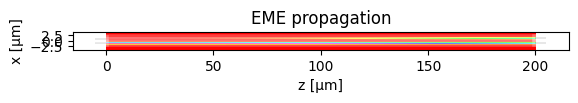

In [30]:
wg_gap =  1.1
wg_width = 1.2 
d = wg_width + wg_gap
wg_N = 2

m1 = DC_EME() 
m1.MMI_num_modes = 12
                    
m1.DC_wg_gap = wg_gap 
m1.DC_wg_width = wg_width 
m1.DC_N_waveguides = wg_N

m1.find_all_modes()
L_pi = m1.get_L_pi()
print("L_pi = ", L_pi, " µm")
m1.L_MMI = 200 
m1.propagation()

c:\Users\cfp\DISEÑO\pic-upv-lab2\.venv\Lib\site-packages\skfem\assembly\form\linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


L_pi =  580.4293623072576  µm


c:\Users\cfp\DISEÑO\pic-upv-lab2\.venv\Lib\site-packages\skfem\assembly\form\linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/4000 [00:00<?, ?it/s]

------- Pameters -------
MMI length 200.0000
MMI length increment 0.0000
IO wg width 1.0000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.8916
Total OUT power: 0.8817
Excess loss [dB] =  0.5470
------------------------
Power over OUTs:  ['0.6473', '0.2343']
Ratio over OUTs ['0.7342', '0.2658']


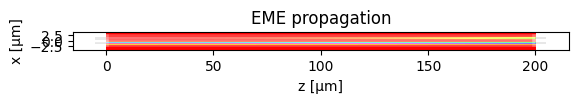

In [31]:
wg_gap =  1.2
wg_width = 1.2 
d = wg_width + wg_gap
wg_N = 2

m1 = DC_EME() 
m1.MMI_num_modes = 12
                    
m1.DC_wg_gap = wg_gap 
m1.DC_wg_width = wg_width 
m1.DC_N_waveguides = wg_N

m1.find_all_modes()
L_pi = m1.get_L_pi()
print("L_pi = ", L_pi, " µm")
m1.L_MMI = 200 
m1.propagation()

c:\Users\cfp\DISEÑO\pic-upv-lab2\.venv\Lib\site-packages\skfem\assembly\form\linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


L_pi =  781.3901391727065  µm


c:\Users\cfp\DISEÑO\pic-upv-lab2\.venv\Lib\site-packages\skfem\assembly\form\linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/4000 [00:00<?, ?it/s]

------- Pameters -------
MMI length 200.0000
MMI length increment 0.0000
IO wg width 1.0000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.8474
Total OUT power: 0.8379
Excess loss [dB] =  0.7683
------------------------
Power over OUTs:  ['0.7093', '0.1285']
Ratio over OUTs ['0.8466', '0.1534']


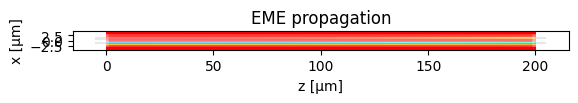

In [32]:
wg_gap =  1.3
wg_width = 1.2 
d = wg_width + wg_gap
wg_N = 2

m1 = DC_EME() 
m1.MMI_num_modes = 12
                    
m1.DC_wg_gap = wg_gap 
m1.DC_wg_width = wg_width 
m1.DC_N_waveguides = wg_N

m1.find_all_modes()
L_pi = m1.get_L_pi()
print("L_pi = ", L_pi, " µm")
m1.L_MMI = 200 
m1.propagation()

c:\Users\cfp\DISEÑO\pic-upv-lab2\.venv\Lib\site-packages\skfem\assembly\form\linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


L_pi =  1050.478684859016  µm


c:\Users\cfp\DISEÑO\pic-upv-lab2\.venv\Lib\site-packages\skfem\assembly\form\linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/4000 [00:00<?, ?it/s]

------- Pameters -------
MMI length 200.0000
MMI length increment 0.0000
IO wg width 1.0000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.7870
Total OUT power: 0.7778
Excess loss [dB] =  1.0912
------------------------
Power over OUTs:  ['0.7100', '0.0678']
Ratio over OUTs ['0.9129', '0.0871']


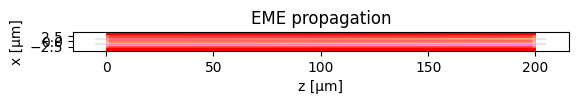

In [33]:
wg_gap =  1.4
wg_width = 1.2 
d = wg_width + wg_gap
wg_N = 2

m1 = DC_EME() 
m1.MMI_num_modes = 12
                    
m1.DC_wg_gap = wg_gap 
m1.DC_wg_width = wg_width 
m1.DC_N_waveguides = wg_N

m1.find_all_modes()
L_pi = m1.get_L_pi()
m1.L_MMI = 200 
print("L_pi = ", L_pi, " µm")
m1.propagation()

c:\Users\cfp\DISEÑO\pic-upv-lab2\.venv\Lib\site-packages\skfem\assembly\form\linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


L_pi =  -1410.6607123702631  µm


c:\Users\cfp\DISEÑO\pic-upv-lab2\.venv\Lib\site-packages\skfem\assembly\form\linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/4000 [00:00<?, ?it/s]

------- Pameters -------
MMI length 200.0000
MMI length increment 0.0000
IO wg width 1.0000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.7299
Total OUT power: 0.7215
Excess loss [dB] =  1.4178
------------------------
Power over OUTs:  ['0.6861', '0.0354']
Ratio over OUTs ['0.9510', '0.0490']


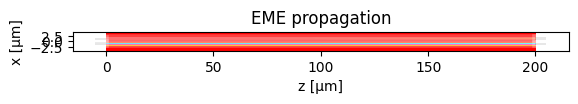

In [36]:
wg_gap =  1.5
wg_width = 1.2 
d = wg_width + wg_gap
wg_N = 2

m1 = DC_EME() 
m1.MMI_num_modes = 12
                    
m1.DC_wg_gap = wg_gap 
m1.DC_wg_width = wg_width 
m1.DC_N_waveguides = wg_N

m1.find_all_modes()
L_pi = m1.get_L_pi()
m1.L_MMI = 200 
print("L_pi = ", L_pi, " µm")
m1.propagation()

c:\Users\cfp\DISEÑO\pic-upv-lab2\.venv\Lib\site-packages\skfem\assembly\form\linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


L_pi =  1892.467412412244  µm


c:\Users\cfp\DISEÑO\pic-upv-lab2\.venv\Lib\site-packages\skfem\assembly\form\linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/4000 [00:00<?, ?it/s]

------- Pameters -------
MMI length 200.0000
MMI length increment 0.0000
IO wg width 1.0000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.6724
Total OUT power: 0.6654
Excess loss [dB] =  1.7691
------------------------
Power over OUTs:  ['0.6471', '0.0183']
Ratio over OUTs ['0.9726', '0.0274']


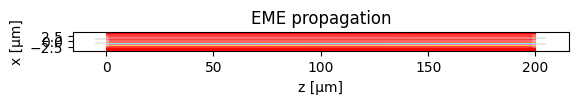

In [37]:
wg_gap =  1.6
wg_width = 1.2 
d = wg_width + wg_gap
wg_N = 2

m1 = DC_EME() 
m1.MMI_num_modes = 12
                    
m1.DC_wg_gap = wg_gap 
m1.DC_wg_width = wg_width 
m1.DC_N_waveguides = wg_N

m1.find_all_modes()
L_pi = m1.get_L_pi()
print("L_pi = ", L_pi, " µm")
m1.L_MMI = 200 
m1.propagation()

## LO.3. Parallel uncoupled waveguides

In [40]:
# HINT. Calculate manually the L_pi you may need to achieve K=0.01
# Then you can sweep the gap and calculate the L_pi until reaching 
# the desired value. 

L= 10*1000 #um
k=0.01
L_pi= L* np.pi/ 2*np.arcsin(np.sqrt(k))
print("L_pi = ", L_pi, " µm")

L_pi =  1573.4261722509552  µm


primero despejamos de la formula l_pi con L=100micrometros. K=0.01. Con ese valor de lpi hacemos un barrido en el gap para averiguarlo

## LO.4. 2x2 Multimode Interference Coupler

### LO.4.1 Propagation Simulation

For the multimode interference (MMI) couplers we must rely on the design tables shown on the theoretical session: 

<img src="mmi.png" alt="Design tables for MMI couplers" width="600">

Here, you will use some functions provided by us (check **0. Imports** for more details) to simulate the propagation in a 2x2 directional coupler. Please read all the comments in the following code carefully and **make changes only to the lines marked with the #Student tag**

In [32]:
# Simulation flow for MMI Couplers
# Define your geometrical parameters here
mmi_Width = 6.6 # Student. Body width

m = MMI_EME() # Here you instantiate a MMI to be simulated with the Eigen-mode expansion (EME) algorithm.
m.MMI_width = mmi_Width
m.MMI_num_modes = 20 # Number of modes to be calculated. Here, the higher, the better since we are going to calculate
                    # the propagation based on the mode decomposition. 

# 1) Compute de MMI body modes - Only execute whenever a geometrical parameter is changed. Takes time to find the modes. 
m.find_all_modes()

# 2) Get the L_pi 
L_pi = m.get_L_pi()
print("L_pi = ", L_pi, " µm")

c:\Users\cfp\pic-upv-lab2\.venv\Lib\site-packages\skfem\assembly\form\linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


L_pi =  69.0359860725655  µm


c:\Users\cfp\pic-upv-lab2\.venv\Lib\site-packages\skfem\assembly\form\linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/690 [00:00<?, ?it/s]

------- Pameters -------
MMI length 34.5180
MMI length increment 0.0000
IO wg width 1.0000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.9604
Total OUT power: 0.9075
Excess loss [dB] =  0.4217
------------------------
Power over OUTs:  ['0.4675', '0.4399']
Ratio over OUTs ['0.5152', '0.4848']


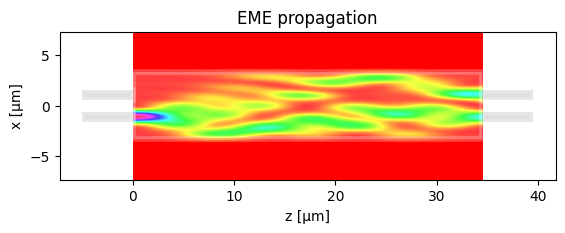

In [34]:
# IMPORTANT!!! 
# # If you DON'T change neither the MMI width 
# nor input/output waveguide widths
# YOU CAN RUN the lines below as many times as you wish
# (SAVES TIME)

# 3) Configure MMI
# # MMI I/O number (check class slides for type of MMI)
m.n_IN =  2 # STUDENT
m.n_OUT = 2 # STUDENT

# MMI I/O waveguide positions (check class slides for type of MMI)
m.IN_WVG_positions = mmi_Width*np.array([-1/6, 1/6]) # STUDENT
m.OUT_WVG_positions = mmi_Width*np.array([-1/6, 1/6]) # STUDENT

# MMI length (check class slides for type of MMI)
m.L_MMI = L_pi/2 # STUDENT

# Run propagation
m.propagation()

### LO.4.2. 2x2 Multimode Interference Coupler - Optimization

  0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/670 [00:00<?, ?it/s]

------- Pameters -------
MMI length 34.5180
MMI length increment -1.0000
IO wg width 1.0000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.9524
Total OUT power: 0.8900
Excess loss [dB] =  0.5062
------------------------
Power over OUTs:  ['0.4402', '0.4498']
Ratio over OUTs ['0.4946', '0.5054']


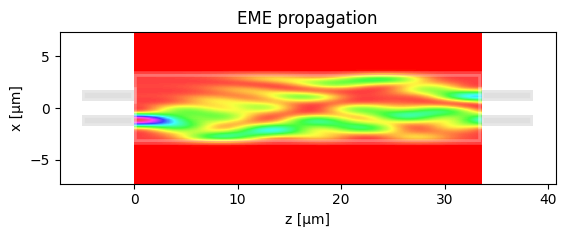

In [35]:
dy = 0.1
# MMI I/O waveguide positions (check class slides for type of MMI)
m.IN_WVG_positions = mmi_Width*np.array([-1/6, 1/6]) + np.array ([-dy, dy]) # STUDENT
m.OUT_WVG_positions = mmi_Width*np.array([-1/6, 1/6]) + np.array ([-dy, dy]) # STUDENT

# MMI length (check class slides for type of MMI)
m.dL_MMI = -1 # STUDENT

# Run propagation
m.propagation()

### LO.4.3 2x2 Multimode Interference Coupler – Optimization (II)

In [36]:
# Design flow for MMI

m = MMI_EME()
m.MMI_width = 6.6   # MMI width
m.wg_width_dw = 0.1 # STUDENT

# 1) Compute de MMI modes
m.find_all_modes()

# 2) Get the L_pi
L_pi = m.get_L_pi()
print("L_pi = ", L_pi, " µm")

c:\Users\cfp\pic-upv-lab2\.venv\Lib\site-packages\skfem\assembly\form\linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


L_pi =  69.03598607255869  µm


c:\Users\cfp\pic-upv-lab2\.venv\Lib\site-packages\skfem\assembly\form\linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/670 [00:00<?, ?it/s]

------- Pameters -------
MMI length 34.5180
MMI length increment -1.0000
IO wg width 1.0000
IO wg width increment 0.1000
------------------------
Total power IN coupled 0.9647
Total OUT power: 0.9005
Excess loss [dB] =  0.4550
------------------------
Power over OUTs:  ['0.4522', '0.4483']
Ratio over OUTs ['0.5022', '0.4978']


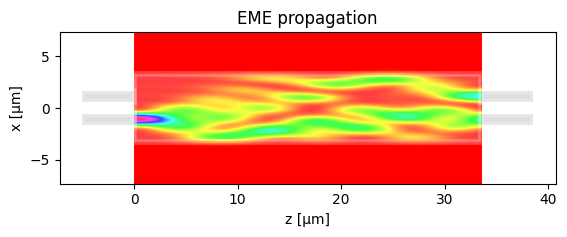

In [38]:
# 3) Configure MMI
# # MMI I/O number (check class slides for type of MMI)
m.n_IN = 2 # STUDENT
m.n_OUT = 2 # STUDENT

dy = 0.0
# MMI I/O waveguide positions (check class slides for type of MMI)
m.IN_WVG_positions =  mmi_Width*np.array([-1/6, 1/6]) + np.array ([-dy, dy])# STUDENT
m.OUT_WVG_positions =  mmi_Width*np.array([-1/6, 1/6]) + np.array ([-dy, dy]) # STUDENT

# MMI length (check class slides for type of MMI)
m.L_MMI = (1/2)* L_pi  # STUDENT
m.dL_MMI = -1 # STUDENT

# Run propagation
m.propagation()

## LO.5. 1x4 1x4 Multimode Interference Coupler 

Repeat the design procedure explained for the 2x2 Coupler to design a 1x4 MMI Coupler. Consider: 
- Select a suitable MMI body width, taking into account that you now must allocate 4 waveguides at the output. 
- Minimize the losses and output imbalance for the MMI coupler. 

## Extra - Exercises

### E1. Directional coupler gap dependence

In [ ]:
gap_to_simulate = 600 * nm # STUDENT. You can manually change the gap
                            # or you can sweep the parameter using a Python for loop. 

deep_dcoupler_cs = gt.modes.WaveguideCoupler(
    wavelength=wavelength, # Wavelength to simulate - Must be a vector
    core_width=(1.0, 1.0), # Waveguide width
    gap=gap_to_simulate,
    slab_thickness=0 * nm, # For shallow waveguides - Set to 0 if its a deep-etched waveguide.
    core_material='sin', #  Material of the waveguide
    clad_material='sio2', # Surrounding material
    core_thickness=300 * nm, # Waveguide height 
    num_modes=4, # Number of modes to find
    cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
    precision='double',
    max_grid_scaling=1.5, # Parameters of the grid
    grid_resolution=20 # Parameters of the grid
)

# STUDENT. Plot goes here


### E2. Directional coupler wavelength dependence

In [ ]:
wavelength = ... # STUDENT code goes here

deep_dcoupler_cs = gt.modes.WaveguideCoupler(
    wavelength=wavelength, # Wavelength to simulate - Must be a vector
    core_width=(1.0, 1.0), # Waveguide width
    gap=600 * nm,
    slab_thickness=0 * nm, # For shallow waveguides - Set to 0 if its a deep-etched waveguide.
    core_material='sin', #  Material of the waveguide
    clad_material='sio2', # Surrounding material
    core_thickness=300 * nm, # Waveguide height 
    num_modes=4, # Number of modes to find
    cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
    precision='double',
    max_grid_scaling=1.5, # Parameters of the grid
    grid_resolution=20 # Parameters of the grid
)

deep_neff = deep_dcoupler_cs.n_eff
L_pi_TE = ... # STUDENT code here

plt.figure(figsize=(10, 5))
plt.scatter(wavelength, L_pi_TE,edgecolors='k',facecolors='none',label = '__nolegend__')
plt.plot(wavelength, L_pi_TE,label='Deep')
plt.xlabel("Wavelength (um)")
plt.ylabel("L_pi")
plt.grid()
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout(rect=[0, 0, 0.85, 1])

### E3. MMI coupler wavelength dependence

In [ ]:
mmi_body_w = 6.6 
lambda_c = ... # STUDENT code goes here.

mmi_body_waveguide = gt.modes.Waveguide(
    # Geometrical Parameters
    core_width=mmi_body_w, # MMI Body width
    core_thickness=300 * nm, # MMI Body height 
    slab_thickness=0 * nm, # For shallow waveguides - Set to 0 if its a deep-etched waveguides.
    # Materials
    core_material='sin', #  Material of the waveguide
    clad_material='sio2', # Surrounding material
    # Modesolver Parameters
    wavelength=lambda_c, # Wavelength to simulate
    num_modes=15, # Targeted number of modes to find - Higher than before! It's a multimode section
    max_grid_scaling=1.5, # Parameters of the grid
    grid_resolution=20, # Parameters of the grid
    cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
    precision='double',
)

d_n_eff = mmi_body_waveguide.n_eff[0].real -  mmi_body_waveguide.n_eff[1].real

L_pi = ... # STUDENT code goes here

# STUDENT plot here. 

### E4. MMI coupler body width dependence

In [ ]:
lambda_c = 1.55

mmi_body_w = 6.6 # STUDENT. You can manually change the body width
                 # or you can sweep the parameter using a Python for loop. 

mmi_body_waveguide = gt.modes.Waveguide(
    # Geometrical Parameters
    core_width=mmi_body_w, # MMI Body width
    core_thickness=300 * nm, # MMI Body height 
    slab_thickness=0 * nm, # For shallow waveguides - Set to 0 if its a deep-etched waveguides.
    # Materials
    core_material='sin', #  Material of the waveguide
    clad_material='sio2', # Surrounding material
    # Modesolver Parameters
    wavelength=lambda_c, # Wavelength to simulate
    num_modes=15, # Targeted number of modes to find - Higher than before! It's a multimode section
    max_grid_scaling=1.5, # Parameters of the grid
    grid_resolution=20, # Parameters of the grid
    cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
    precision='double',
)

d_n_eff = mmi_body_waveguide.n_eff[0].real -  mmi_body_waveguide.n_eff[1].real

L_pi = ... # STUDENT code goes here

# STUDENT plot here. 